Part 2: Computer Vision Problem Formulation and CNN Prototype

Task 1: Problem Identification

The dataset represents an image classification problem because each image belongs to exactly one predefined category:

- normal
- scratch
- dent
- stain

The goal of the model is to analyze an input image and predict which class label it belongs to based on its visual appearance.

In this dataset:

Each image contains a single product surface.
The labels describe the overall condition of the product.
The task does not require locating defects with bounding boxes.
The task does not require pixel-level masks.

Therefore, the model only needs to assign one class label per image, which is the definition of image classification.

The rest are not appropriate as:
Object detection identifies and locates objects using bounding boxes.

This dataset does not provide:
- object coordinates
- bounding boxes

Semantic segmentation classifies every pixel in an image.

This dataset does not contain:
- pixel-level masks
- segmentation annotations

Instance segmentation separates individual object instances using masks.

This dataset does not include:
- individual defect instance labels
- object masks

In [ ]:
# Task 2: Dataset Exploration
# 1. Number of Classes : The dataset contains 4 classes: 'normal', 'scratch', 'dent', 'stain'
# These classes represent different surface conditions of manufactured products.
! pip3 install opencv-python
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

dataset_path = r"C:\Users\sriva\Downloads\ai_project_synthetic_datasets-20260505T144938Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"

classes = ["normal", "scratch", "dent", "stain"]

image_count = {}

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    count = len(os.listdir(class_path))

    image_count[cls] = count

# Display counts
for cls, count in image_count.items():
    print(f"{cls}: {count} images")



normal: 120 images
scratch: 120 images
dent: 120 images
stain: 120 images


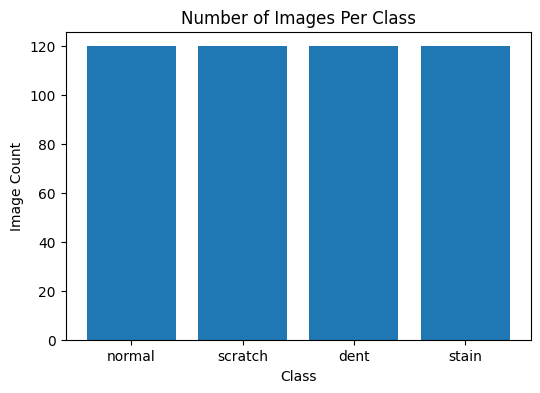

In [ ]:
# Visualize class distribution
plt.figure(figsize=(6,4))

plt.bar(image_count.keys(), image_count.values())

plt.title("Number of Images Per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")

plt.show()

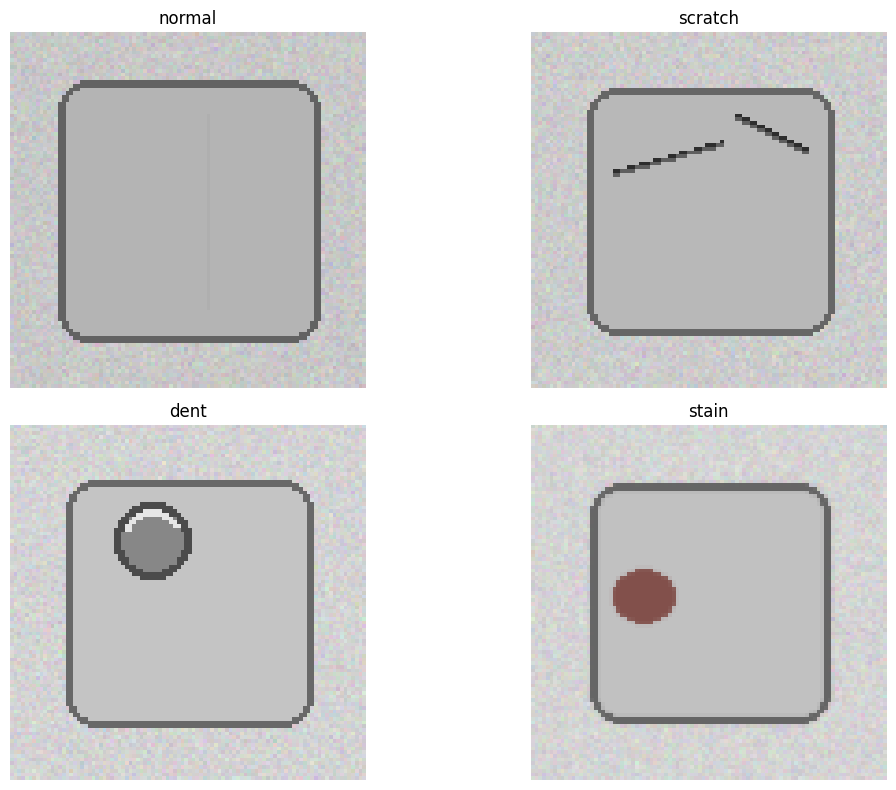

In [ ]:
# Display sample images from each class
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    sample_image = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, sample_image)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# Check image dimensions
dimensions = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        height, width, channels = img.shape

        dimensions.append((height, width, channels))

# Unique dimensions
unique_dimensions = set(dimensions)

print("Unique image dimensions:")
print(unique_dimensions)

Unique image dimensions:
{(96, 96, 3)}


Final Observation: The dataset is suitable for a CNN-based image classification task because:
- images are grouped into clear categories
- defect patterns are visually distinguishable
- labels are already organized by class folders or CSV annotations
- since all four classes contain 120 images each, therefore, there is no imbalance in dataset.

This will help CNN learn all classes equally.

In [ ]:
# Task 3: Image Preprocessing
import os
import numpy as np
from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array,
    ImageDataGenerator
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

dataset_path = r"C:\Users\sriva\Downloads\ai_project_synthetic_datasets-20260505T144938Z-3-001\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"

classes = ["normal", "scratch", "dent", "stain"]

IMAGE_SIZE = (96, 96)

data = []
labels = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        # Load image and resize
        img = load_img(
            img_path,
            target_size=IMAGE_SIZE
        )

        # Convert image to array
        img_array = img_to_array(img)

        data.append(img_array)
        labels.append(cls)

# Convert to NumPy arrays
X = np.array(data, dtype="float32")
y = np.array(labels)

print("Dataset shape:", X.shape)

# Normalizing pixel values to [0, 1]
X = X / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())


Dataset shape: (480, 96, 96, 3)
Minimum pixel value: 0.1764706
Maximum pixel value: 1.0


In [ ]:
# Encoding labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# One-hot encoding
y_categorical = to_categorical(y_encoded)

print("Classes:", encoder.classes_)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Classes: ['dent' 'normal' 'scratch' 'stain']
Training set shape: (384, 96, 96, 3)
Testing set shape: (96, 96, 96, 3)


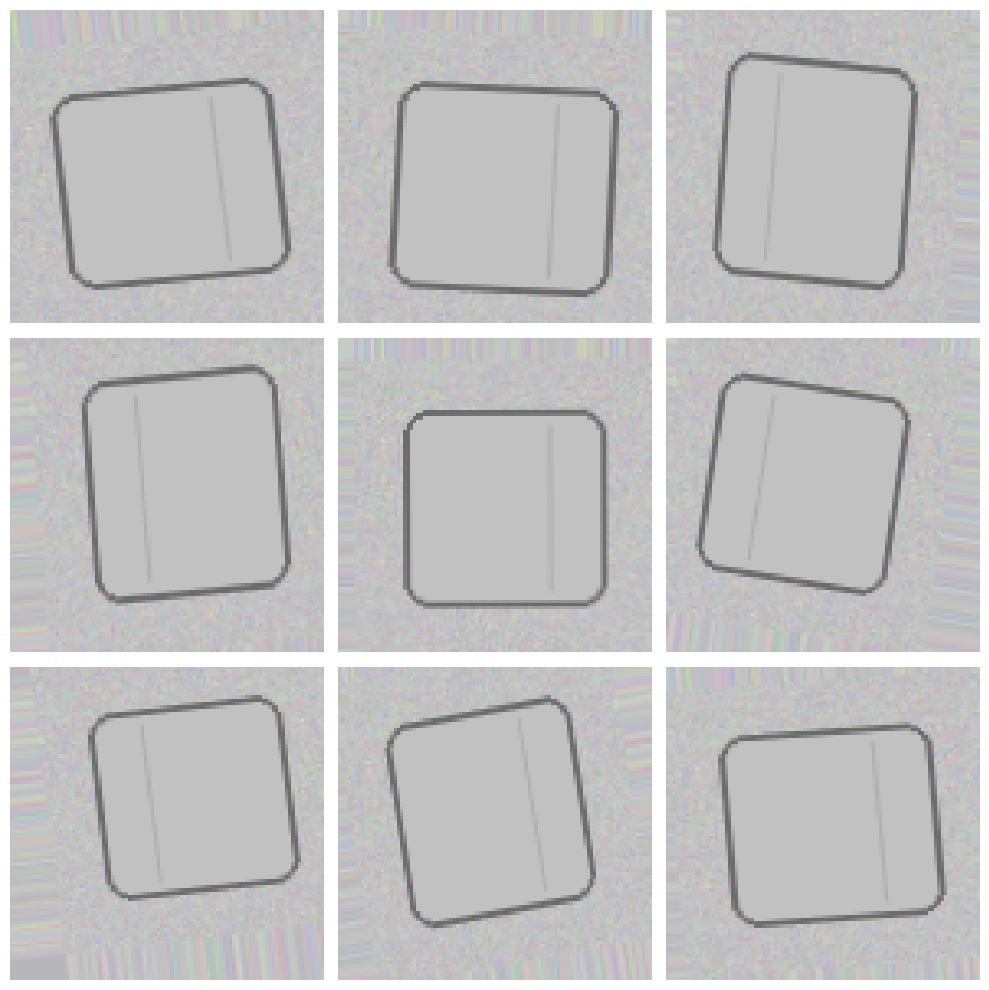

In [ ]:
# Data augmentation
train_datagen = ImageDataGenerator(

    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
# Only rescaling for test data
test_datagen = ImageDataGenerator()

# Generate augmented batches
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

test_generator = test_datagen.flow(
    X_test,
    y_test,
    batch_size=32
)

# Display augmented images
sample_image = X_train[0]

sample_image = np.expand_dims(sample_image, axis=0)

augmented_images = train_datagen.flow(sample_image, batch_size=1)

plt.figure(figsize=(10,10))

for i in range(9):

    batch = next(augmented_images)

    image = batch[0]

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.axis("off")

plt.tight_layout()

plt.show()

Task 4: CNN Model Creation

In [ ]:
# import libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Building CNN model
model = Sequential()
# First Convolution Block
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',     # Adding ReLU activation for non-linearity. This helps the CNN learn complex image features.
        input_shape=(96,96,3)
    )
)
# Adding Pooling layer after the first convolutional layer to reduce spatial dimensions
model.add(
    MaxPooling2D(pool_size=(2,2)) # Max pooling reduces feature map dimensions while preserving important information. It reduces reduces computation load and reduces overfitting
)

# Second Convolution Block
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Third Convolution Block
model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    )
)
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer: converts 2D feature maps into a 1D vector so they can be passed into dense layers.
model.add(Flatten())

# Dense Layers. It performs final classification learning using extracted image features.
model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(Dropout(0.5))

# Output Layer
model.add(
    Dense(
        4,
        activation='softmax' # because the dataset has 4 classes, Softmax converts outputs into probabilities. The class with the highest probability becomes the predicted label.
    )
)

# Display Model Architecture
model.summary()

c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.2474 - loss: 1.4565 - val_accuracy: 0.2500 - val_loss: 1.3861
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.2370 - loss: 1.3902 - val_accuracy: 0.4583 - val_loss: 1.3825
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.2786 - loss: 1.3785 - val_accuracy: 0.3750 - val_loss: 1.3644
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.3802 - loss: 1.3398 - val_accuracy: 0.3229 - val_loss: 1.2808
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.4635 - loss: 1.2217 - val_accuracy: 0.7083 - val_loss: 1.0934
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5755 - loss: 1.0603 - val_accuracy: 0.6250 - val_loss: 0.8556
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.6198 - loss: 0.8535 - val_accuracy: 0.7708 - val_loss: 0.6998
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.7083 - loss: 0.7269 - val_accuracy: 0.

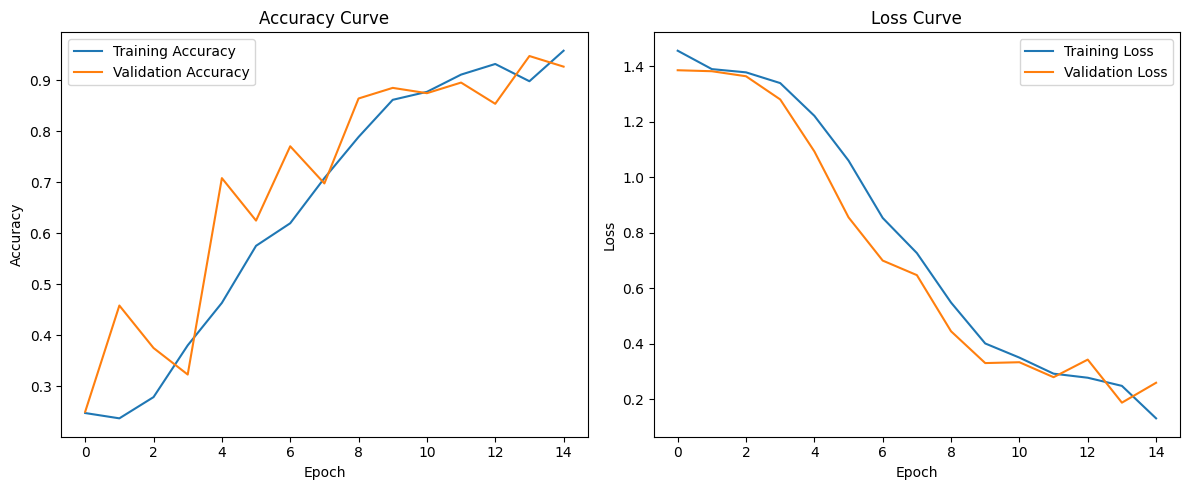

In [ ]:
# Train CNN model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)
# Plot training and validation accuracy and loss curves

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy Curve
plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# Loss Curve
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()




In [ ]:
# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9271 - loss: 0.2593
Test Loss: 0.25928208231925964
Test Accuracy: 0.9270833134651184


In [ ]:
# Generate predictions and print classification report
import numpy as np

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=encoder.classes_
    )
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
              precision    recall  f1-score   support

        dent       0.88      0.88      0.88        24
      normal       1.00      0.96      0.98        24
     scratch       0.84      0.88      0.86        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.93        96
   macro avg       0.93      0.93      0.93        96
weighted avg       0.93      0.93      0.93        96



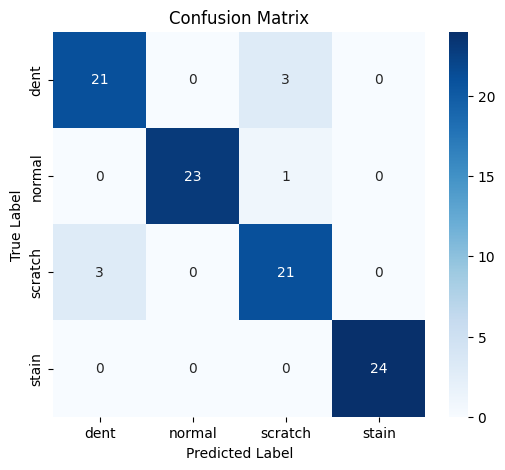

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

Sample Predictions

The prediction visualization helps verify whether the CNN correctly identifies: scratches, dents, stains, normal surfaces on actual test images.

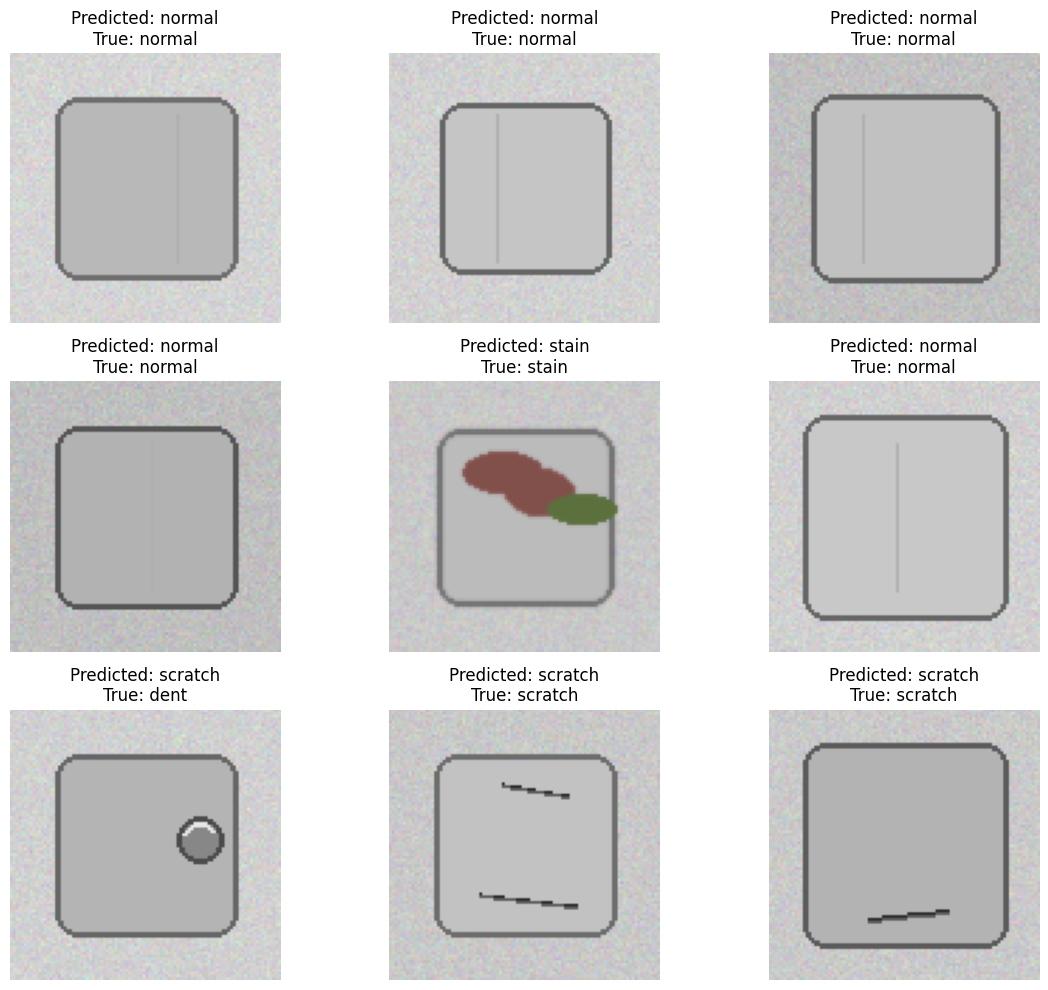

In [ ]:
# Display sample predictions
plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    predicted_label = encoder.inverse_transform(
        [predicted_classes[i]]
    )[0]

    true_label = encoder.inverse_transform(
        [true_classes[i]]
    )[0]

    plt.title(
        f"Predicted: {predicted_label}\nTrue: {true_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

Final Evaluation Summary

The CNN model successfully learns visual defect patterns from manufacturing images using:

- convolution operations
- activation functions
- pooling layers
- dense classification layers

The evaluation results demonstrate the model’s ability to classify product defects automatically, making it suitable for manufacturing quality inspection tasks.